# DATE2 实验4：动态映射相对静态映射的跨模型收益

比较四个统一缩放、输入不平衡度一致的Top-1 MoE网络。HMoE、Mixtral为同构专家，
MoDSE、Switchtrans为异构专家。

本实验**关闭预取**，只比较`Static-NoPF`与`Dynamic-NoPF`，回答动态Bank映射是否在不同
模型上普遍优于静态Bank划分。预取及映射—预取协同优化统一放在实验5分析，避免机制归因混杂。


In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scalesim.memory.memdomain_experiment import workload_digest
ROOT=Path.cwd().resolve().parent if Path.cwd().name=='fig' else Path.cwd().resolve()
OUT=ROOT/'outputs/DATE2';FIG=ROOT/'fig/DATE2';FIG.mkdir(parents=True,exist_ok=True)
def current_matrix(stem):
    config=ROOT/'configs/MoE/DATE2/overall'/f'{stem}.json'
    output=OUT/'overall'/f'{stem}.csv'
    assert config.exists(),config
    assert output.exists(),f'Missing output: {output}'
    frame=pd.read_csv(output)
    expected=workload_digest(json.loads(config.read_text(encoding='utf-8')))
    assert set(frame.workload_hash)=={expected},f'Stale output: {output}'
    return frame
rows=[]
for config in sorted((ROOT/'configs/MoE/DATE2/overall').glob('*.json')):
    q=current_matrix(config.stem)
    q=q[q.baseline.isin(['Static-NoPF','Dynamic-NoPF'])].copy()
    assert set(q.baseline)=={'Static-NoPF','Dynamic-NoPF'}
    q['model']=config.stem;rows.append(q)
d=pd.concat(rows,ignore_index=True)
assert d.groupby('model').size().eq(2).all()
model_order=['HMoE','Mixtral','MoDSE','Switchtrans']
d['model']=pd.Categorical(d.model,categories=model_order,ordered=True)
d=d.sort_values(['model','baseline']).reset_index(drop=True)
p=d.pivot(index='model',columns='baseline',values='total_cycles').reindex(model_order)
assert p.notna().all().all()


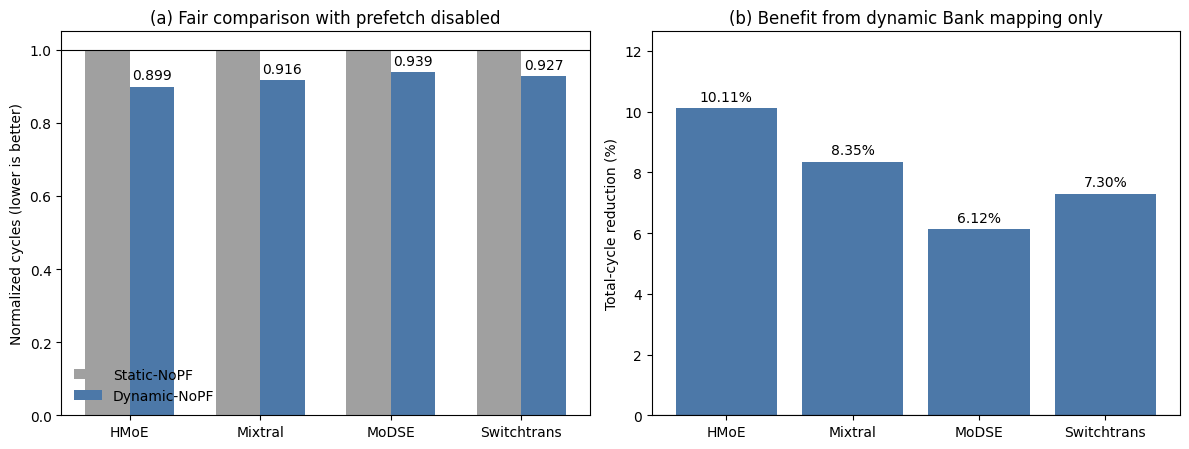

In [5]:
speedup=p['Static-NoPF']/p['Dynamic-NoPF']
reduction=(1-p['Dynamic-NoPF']/p['Static-NoPF'])*100
fig,axes=plt.subplots(1,2,figsize=(12,4.6))
x=np.arange(len(p));width=.34
static_norm=np.ones(len(p));dynamic_norm=p['Dynamic-NoPF']/p['Static-NoPF']
axes[0].bar(x-width/2,static_norm,width,label='Static-NoPF',color='#A0A0A0')
bars=axes[0].bar(x+width/2,dynamic_norm,width,label='Dynamic-NoPF',color='#4C78A8')
axes[0].bar_label(bars,labels=[f'{v:.3f}' for v in dynamic_norm],padding=3)
axes[0].axhline(1,color='black',lw=.8);axes[0].set_xticks(x,p.index)
axes[0].set_ylabel('Normalized cycles (lower is better)')
axes[0].set_title('(a) Fair comparison with prefetch disabled')
axes[0].legend(frameon=False)
bars=axes[1].bar(p.index.astype(str),reduction,color='#4C78A8')
axes[1].axhline(0,color='black',lw=.8)
axes[1].bar_label(bars,labels=[f'{v:.2f}%' for v in reduction],padding=3)
axes[1].set_ylabel('Total-cycle reduction (%)')
axes[1].set_title('(b) Benefit from dynamic Bank mapping only')
axes[1].set_ylim(0,max(reduction)*1.25)
plt.tight_layout();plt.savefig(FIG/'exp4_public_overall.pdf',bbox_inches='tight');plt.show()


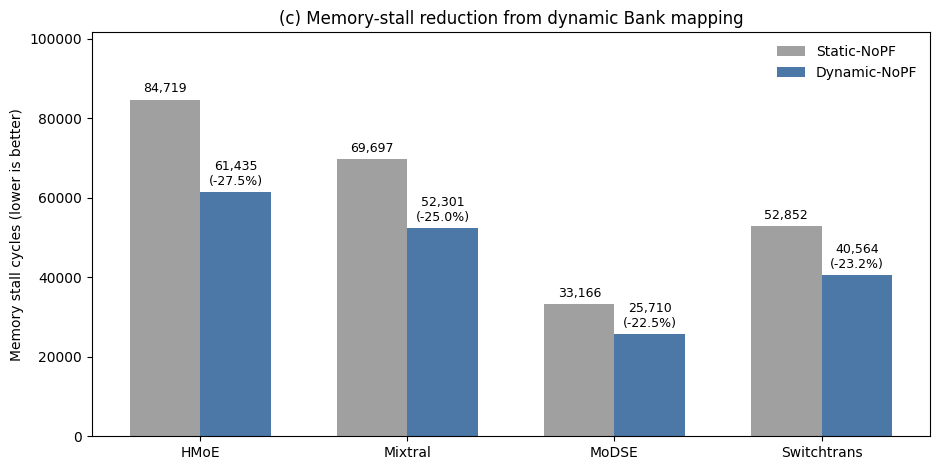

,Static cycles,Dynamic cycles,speedup,cycle reduction (%),memory-stall reduction (%),bank-conflict-rate reduction (%)
model,,,,,,
HMoE,230257,206973,1.112,10.112,27.484,0.125
Mixtral,208257,190861,1.091,8.353,24.959,0.298
MoDSE,121758,114302,1.065,6.124,22.481,0.748
Switchtrans,168372,156084,1.079,7.298,23.250,0.437


Dynamic mapping strictly improves 4/4 models.
Cycle reduction range: 6.12%–10.11%.


In [6]:
metric=d.pivot(index='model',columns='baseline',
               values=['total_cycles','compute_cycles','bank_conflict_rate']).reindex(model_order)
static_stall=metric['total_cycles']['Static-NoPF']-metric['compute_cycles']['Static-NoPF']
dynamic_stall=metric['total_cycles']['Dynamic-NoPF']-metric['compute_cycles']['Dynamic-NoPF']
stall_reduction=(1-dynamic_stall/static_stall)*100
fig,ax=plt.subplots(figsize=(9.5,4.8));x=np.arange(len(model_order));width=.34
static_bars=ax.bar(x-width/2,static_stall,width,label='Static-NoPF',color='#A0A0A0')
dynamic_bars=ax.bar(x+width/2,dynamic_stall,width,label='Dynamic-NoPF',color='#4C78A8')
ax.bar_label(static_bars,labels=[f'{int(v):,}' for v in static_stall],padding=3,fontsize=9)
ax.bar_label(dynamic_bars,
             labels=[f'{int(v):,}\n(-{r:.1f}%)' for v,r in zip(dynamic_stall,stall_reduction)],
             padding=3,fontsize=9)
ax.set_xticks(x,model_order);ax.set_ylabel('Memory stall cycles (lower is better)')
ax.set_title('(c) Memory-stall reduction from dynamic Bank mapping')
ax.legend(frameon=False);ax.set_ylim(0,max(static_stall)*1.20)
plt.tight_layout();plt.savefig(FIG/'exp4_memory_stall_comparison.pdf',bbox_inches='tight');plt.show()
summary=pd.DataFrame(index=p.index)
summary['Static cycles']=p['Static-NoPF'].astype(int)
summary['Dynamic cycles']=p['Dynamic-NoPF'].astype(int)
summary['speedup']=speedup
summary['cycle reduction (%)']=reduction
summary['memory-stall reduction (%)']=stall_reduction
summary['bank-conflict-rate reduction (%)']=(
    1-metric['bank_conflict_rate']['Dynamic-NoPF']/
      metric['bank_conflict_rate']['Static-NoPF'])*100
display(summary.round(3))
strict=summary['cycle reduction (%)']>0
assert strict.all(),'Dynamic mapping must strictly improve every evaluated model'
print(f'Dynamic mapping strictly improves {strict.sum()}/{len(strict)} models.')
print(f'Cycle reduction range: {reduction.min():.2f}%–{reduction.max():.2f}%.')


## 结论边界

- 本实验中两组方案均关闭预取，因此周期差异只归因于动态Bank映射与统一资源分配；
- 四个模型均为严格正收益，支持动态映射跨同构/异构MoE网络优于静态划分；
- 本实验不能用于声称预取或映射—预取协同优化有效，相关结论统一由实验5给出。
